# EDA

Сначала проверим исходный датасет перед подготовкой данных.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 50)

In [3]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

raw_path = project_root / "data" / "raw" / "dataset.csv"

raw_path

WindowsPath('C:/Projects/guest-predictor/data/raw/dataset.csv')

In [4]:
raw = pd.read_csv(raw_path, parse_dates=["date"])
raw = raw.sort_values(["restaurant_id", "date"]).reset_index(drop=True)

raw.head()

,date,restaurant_id,guests,revenue
0,2024-01-01,1,51.0,65051.0
1,2024-01-02,1,61.0,104470.0
2,2024-01-03,1,86.0,124256.0
3,2024-01-04,1,90.0,124270.0
4,2024-01-05,1,91.0,133742.0


In [5]:
raw.shape

(2958, 4)

In [6]:
raw.dtypes

date             datetime64[us]
restaurant_id             int64
guests                  float64
revenue                 float64
dtype: object

Видим, что в исходном сыром датасете есть только четыре базовые колонки: дата, идентификатор точки, число гостей и выручка. Количество строк - 2958

In [7]:
summary = pd.DataFrame(
    {
        "rows": [len(raw)],
        "min_date": [raw["date"].min()],
        "max_date": [raw["date"].max()],
        "restaurants": [raw["restaurant_id"].nunique()],
    }
)

summary

,rows,min_date,max_date,restaurants
0,2958,2024-01-01,2026-09-30,3


Видим, что датасет покрывает больше 30 месяцев истории и содержит три ресторана.

In [8]:
duplicates = raw.duplicated(subset=["restaurant_id", "date"]).sum()
duplicates

np.int64(0)

Видим, что дубли отсутствуют

In [9]:
raw.isna().sum()

date              0
restaurant_id     0
guests            9
revenue          12
dtype: int64

Видим, что имеются частично заполненные строки

In [10]:
calendar_gaps = []

for restaurant_id, group in raw.groupby("restaurant_id"):
    full_dates = pd.date_range(group["date"].min(), group["date"].max(), freq="D")
    observed_dates = pd.Index(group["date"])
    missing_dates = full_dates.difference(observed_dates)

    calendar_gaps.append(
        {
            "restaurant_id": restaurant_id,
            "expected_days": len(full_dates),
            "observed_days": len(group),
            "missing_days": len(missing_dates),
        }
    )

calendar_gaps = pd.DataFrame(calendar_gaps)
calendar_gaps

,restaurant_id,expected_days,observed_days,missing_days
0,1,1004,986,18
1,2,1004,986,18
2,3,1004,986,18


Вывод: в raw-датасете есть пропущенные календарные дни.

In [11]:
zero_days = (
    raw.assign(is_zero_day=(raw["guests"].eq(0) & raw["revenue"].eq(0)))
    .groupby("restaurant_id")["is_zero_day"]
    .agg(["sum", "mean"])
    .rename(columns={"sum": "zero_days", "mean": "zero_day_share"})
)

zero_days

,zero_days,zero_day_share
restaurant_id,,
1,6,0.006085
2,150,0.152130
3,9,0.009128


Видим, что имеются нулевые дни, которые отличаются от просто пропущенных дат. Их можно интерпретировать как нерабочий день

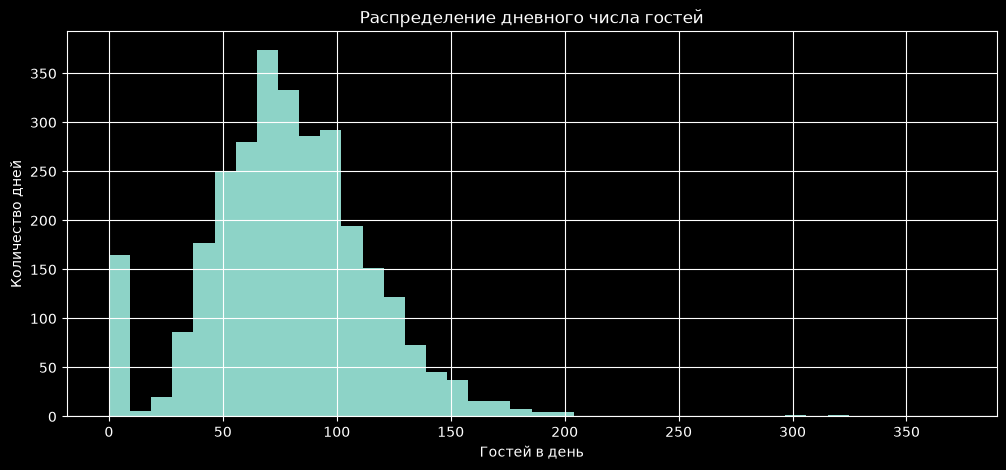

In [12]:
raw["guests"].hist(bins=40)

plt.title("Распределение дневного числа гостей")
plt.xlabel("Гостей в день")
plt.ylabel("Количество дней")
plt.show()

На гистограмме можно увидеть типичный дневной поток и крайние значения. Показано распределение целевой переменной - числа гостей.

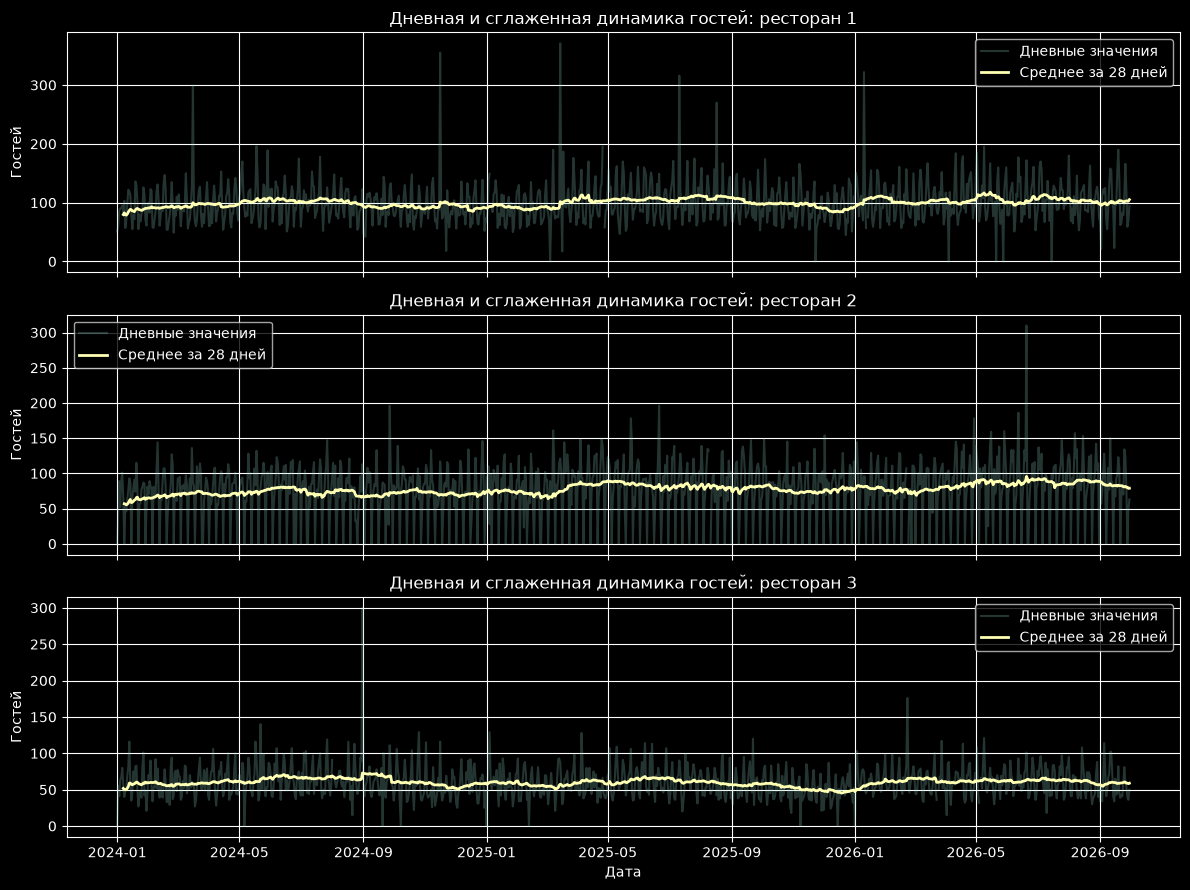

In [13]:
restaurant_ids = sorted(raw["restaurant_id"].unique())

fig, axes = plt.subplots(
    nrows=len(restaurant_ids),
    ncols=1,
    figsize=(12, 3 * len(restaurant_ids)),
    sharex=True,
)

for ax, restaurant_id in zip(axes, restaurant_ids):
    group = raw[raw["restaurant_id"].eq(restaurant_id)].copy()
    group["guests_28d_mean"] = group["guests"].rolling(28, min_periods=7).mean()

    ax.plot(
        group["date"],
        group["guests"],
        alpha=0.25,
        label="Дневные значения",
    )

    ax.plot(
        group["date"],
        group["guests_28d_mean"],
        linewidth=2,
        label="Среднее за 28 дней",
    )

    ax.set_title(f"Дневная и сглаженная динамика гостей: ресторан {restaurant_id}")
    ax.set_ylabel("Гостей")
    ax.legend()

axes[-1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

Графики позволяют оценить тренд, сезонность, провалы до нуля и отдельные резкие всплески.

In [14]:
month_stats = raw.copy()
month_stats["month"] = month_stats["date"].dt.month

monthly = (
    month_stats.groupby("month")["guests"]
    .mean()
    .reset_index()
    .sort_values("month")
)

monthly

,month,guests
0,1,76.468864
1,2,74.473684
2,3,80.095238
3,4,80.477099
4,5,85.465201
5,6,83.022642
6,7,83.091912
7,8,81.824818
8,9,77.071161
9,10,74.577778


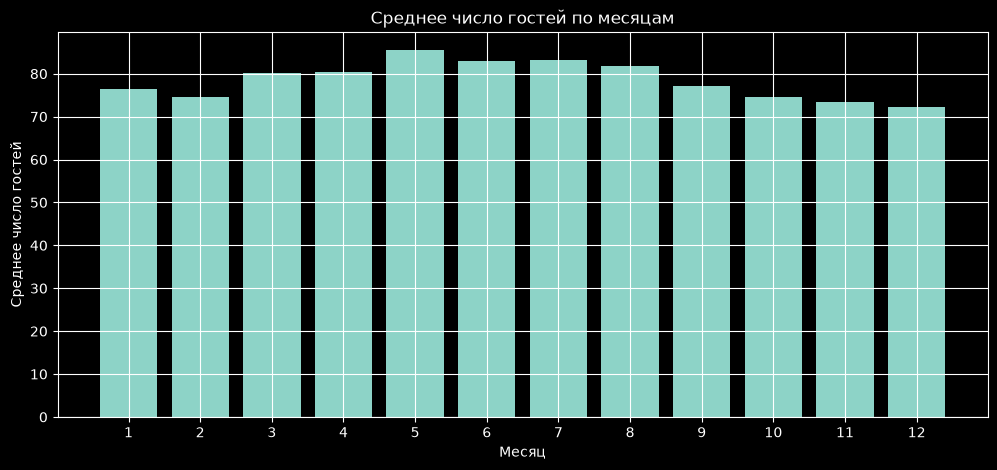

In [15]:
plt.bar(monthly["month"], monthly["guests"])

plt.title("Среднее число гостей по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Среднее число гостей")
plt.xticks(range(1, 13))
plt.show()

Можно увидеть более наглядную зависимость числа гостей от месяца (сезона)

In [16]:
dow_stats = raw.copy()
dow_stats["dow"] = dow_stats["date"].dt.dayofweek
dow_stats["dow_name"] = dow_stats["date"].dt.day_name()

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekly = (
    dow_stats.groupby(["dow", "dow_name"])["guests"]
    .mean()
    .reset_index()
    .sort_values("dow")
)

weekly

,dow,dow_name,guests
0,0,Monday,36.346604
1,1,Tuesday,62.919048
2,2,Wednesday,72.988180
3,3,Thursday,81.336493
4,4,Friday,100.317536
5,5,Saturday,113.877990
6,6,Sunday,86.213429


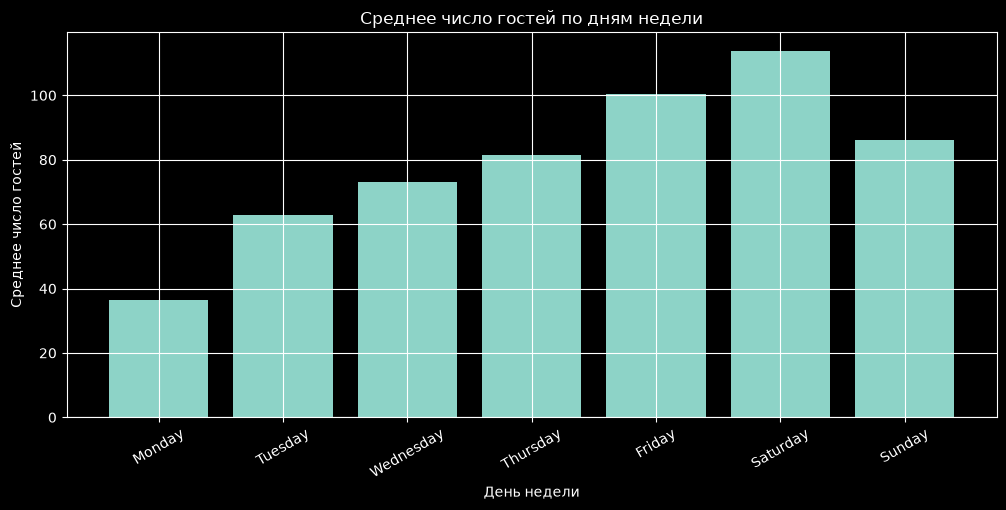

In [17]:
plt.bar(weekly["dow_name"], weekly["guests"])

plt.title("Среднее число гостей по дням недели")
plt.xlabel("День недели")
plt.ylabel("Среднее число гостей")
plt.xticks(rotation=30)
plt.show()

Как видим, недельная сезонность важна для модели, потому что поток гостей заметно зависит от дня недели

In [18]:
outlier_rows = []

for restaurant_id, group in raw.groupby("restaurant_id"):
    q1 = group["guests"].quantile(0.25)
    q3 = group["guests"].quantile(0.75)
    iqr = q3 - q1

    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr

    count = group["guests"].lt(lower).sum() + group["guests"].gt(upper).sum()

    outlier_rows.append(
        {
            "restaurant_id": restaurant_id,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_days": count,
        }
    )

outliers = pd.DataFrame(outlier_rows)
outliers

,restaurant_id,lower_bound,upper_bound,outlier_days
0,1,14.75,180.75,21
1,2,7.00,159.00,158
2,3,4.50,112.50,29


Видим, что встречаются экстремальные значения. Часть может быть реальными событиями, а часть — аномалиями. На этапе подготовки данных их нужно обработать